In [1]:
#TODO set good xticks

In [1]:
from core.sr_study_analysis import run_analysis, run_selected_configs, ExperimentSpec
from core.sr_sim import StudyType

## Scenarios and parameter grids

In [2]:
# name : (dgp_names, model_short_names)
scenarios = {
    "tails": (
        ["iid_t6"],
        ["iid_normal", "iid_student_t", "iid_nonnormal"],
    ),
    "skew": (
        ["iid_skewt60_m05", "iid_skewt6_m05"],
        ["iid_normal", "iid_student_t", "iid_nonnormal"],
    ),
    "non4": (
        ["iid_t3", "iid_t6"],
        ["iid_student_t"],
    ),
    "serial": (
        ["ar1_06_normal", "ar1_m06_normal"],
        ["iid_normal", "ar1_normal"],
    ),
    "hetero_tails": (
        ["garch_normal"],
        ["iid_normal", "iid_nonnormal", "garch11"],
    ),
    "efficiency": (
        ["iid_normal"],
        ["iid_normal", "iid_student_t", "iid_nonnormal", "ar1_normal", "ar1_nonnormal"],
    ),
}

parameters = {
    "sr":    [0.5, 1.0, 1.5],
    "T":     [100, 500, 2_000],
    "n_sim": [1_000, 10_000, 50_000],
}

## Experiment registry

In [14]:
N_SIM  = 30_000
N_JOBS = 8

experiments = {
    # ── two-sided coverage (original) ────────────────────────────────────────
    "tails": ExperimentSpec(
        scenario   = scenarios["tails"],
        param_name = "T",
        param_values = parameters["T"],
        study_type = StudyType.TWO_SIDED_COVERAGE,
        calib_sigma   = 1.0,
        sr_default = 0.5,
        th_moments = False,
        n_default  = N_SIM, n_jobs = N_JOBS,
        seed=51
    ),
    "tails_th": ExperimentSpec(
        scenario   = scenarios["tails"],
        param_name = "T",
        param_values = parameters["T"],
        study_type = StudyType.TWO_SIDED_COVERAGE,
        calib_sigma   = 1.0,
        sr_default = 0.5,
        th_moments = True,
        n_default  = N_SIM, n_jobs = N_JOBS,
    ),
    "skew": ExperimentSpec(
        scenario   = scenarios["skew"],
        param_name = "T",
        param_values = parameters["T"],
        study_type = StudyType.TWO_SIDED_COVERAGE,
        calib_sigma   = 1.0,
        sr_default = 0.5,
        th_moments = False,
        n_default  = N_SIM, n_jobs = N_JOBS,
    ),
    "non4": ExperimentSpec(
        scenario   = scenarios["non4"],
        param_name = "T",
        param_values = parameters["T"],
        study_type = StudyType.TWO_SIDED_COVERAGE,
        calib_sigma   = 1.0,
        n_default  = N_SIM, n_jobs = N_JOBS,
    ),
    "serial": ExperimentSpec(
        scenario   = scenarios["serial"],
        param_name = "T",
        param_values = parameters["T"],
        study_type = StudyType.TWO_SIDED_COVERAGE,
        calib_sigma   = 1.0,
        n_default  = N_SIM, n_jobs = N_JOBS,
    ),
    "hetero_tails": ExperimentSpec(
        scenario   = scenarios["hetero_tails"],
        param_name = "sr",
        param_values = parameters["sr"],
        study_type = StudyType.TWO_SIDED_COVERAGE,
        calib_sigma   = 1.0,
        th_moments = True,
        n_default  = N_SIM, n_jobs = N_JOBS,
    ),
    "efficiency": ExperimentSpec(
        scenario   = scenarios["efficiency"],
        #param_name = "n_sim",
        #param_values = [100, 1000, 5000, 10_000, 50_000],
        param_name = "T",
        param_values = parameters["T"],
        study_type = StudyType.TWO_SIDED_COVERAGE,
        calib_sigma   = 1.0,
        th_moments = False,
        #T_default=50,
        n_default  = N_SIM,
        n_jobs = N_JOBS,
    ),
}

---
## EXECUTION

In [15]:
# ── coverage / size runs ──────────────────────────────────────────────────────
run_selected_configs(
    experiments,
    selected_experiments=[
        #"tails",
        #"tails_th",
        #"skew",
        #"non4",
        #"serial",
        #"hetero_tails",
        "efficiency",
    ],
)


  Experiment: efficiency
  [1/3]  T=100  (TWO_SIDED_COVERAGE)
  [2/3]  T=500  (TWO_SIDED_COVERAGE)
  [3/3]  T=2000  (TWO_SIDED_COVERAGE)


---
## VISUALIZATION

In [5]:
#common
line_plot_kargs = dict(reverse=False, 
                       linewidth=1,)

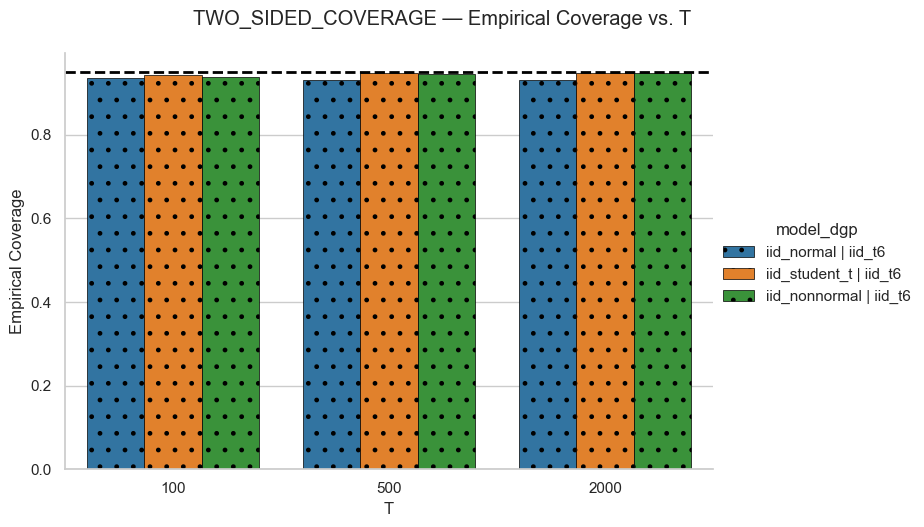

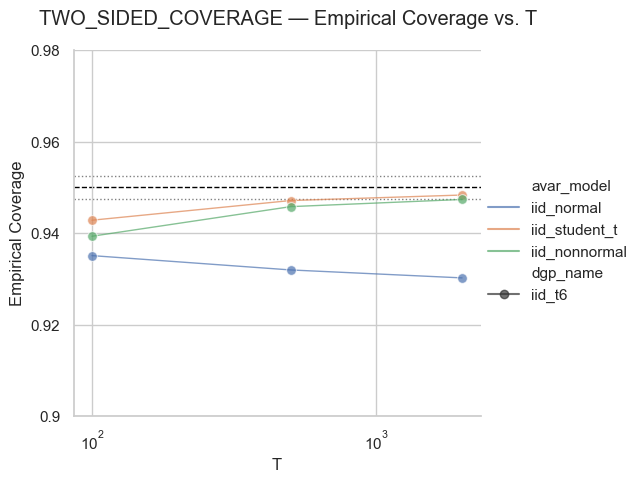

In [7]:
run_analysis(experiments, "tails", alpha=0.05, plot_mask=[0,1,1],
             line_plot_kargs=line_plot_kargs |
             dict(log=True, yticks=[0.9, 0.92, 0.94, 0.96, 0.98]))

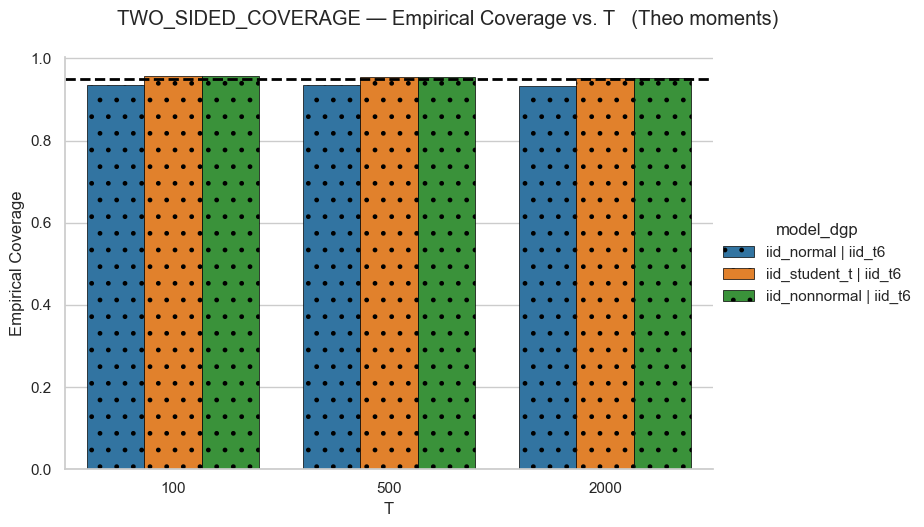

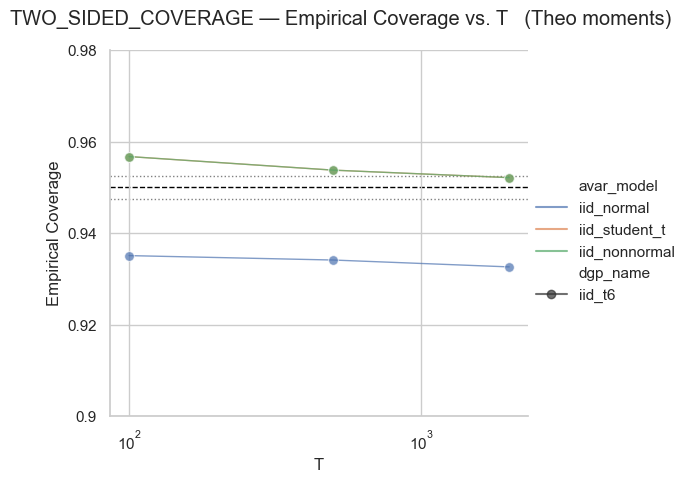

In [8]:
run_analysis(experiments, "tails_th", alpha=0.05, plot_mask=[0,1,1],
             line_plot_kargs=line_plot_kargs | 
             dict(log=True, yticks=[0.9, 0.92, 0.94, 0.96, 0.98]))

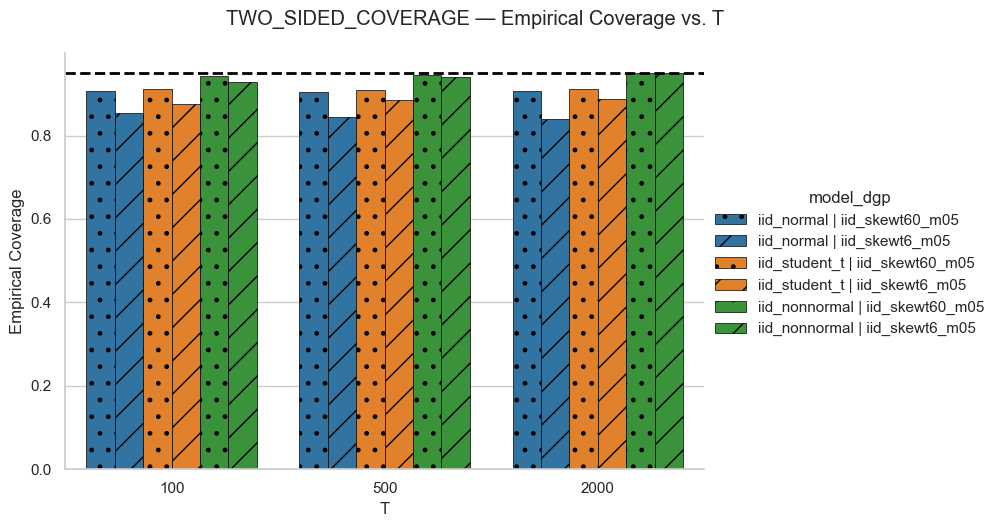

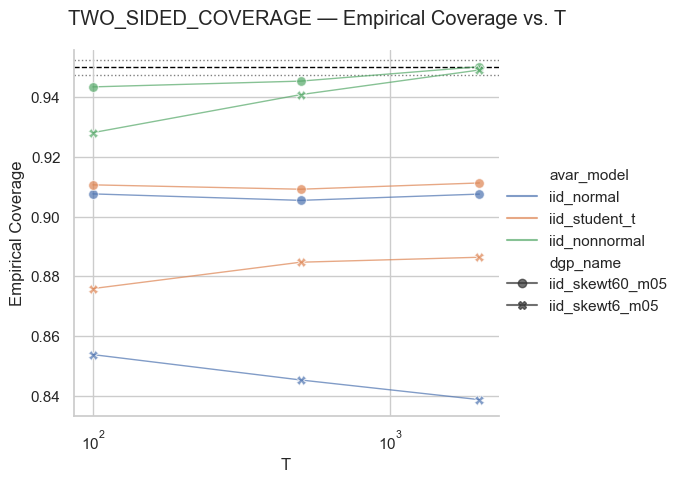

In [9]:
run_analysis(experiments, "skew", alpha=0.05, plot_mask=[0,1,1],
             line_plot_kargs=line_plot_kargs | 
             dict(log=True, markers=['o', 'X']))

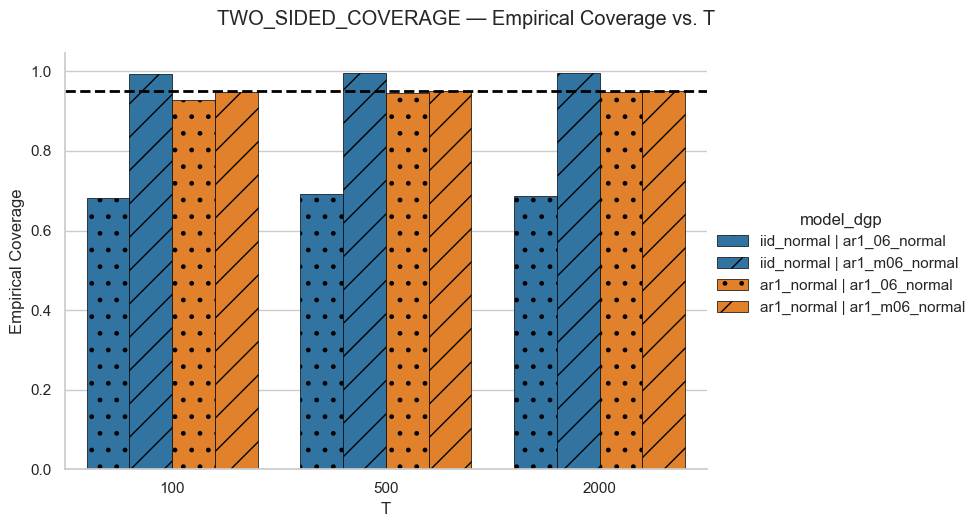

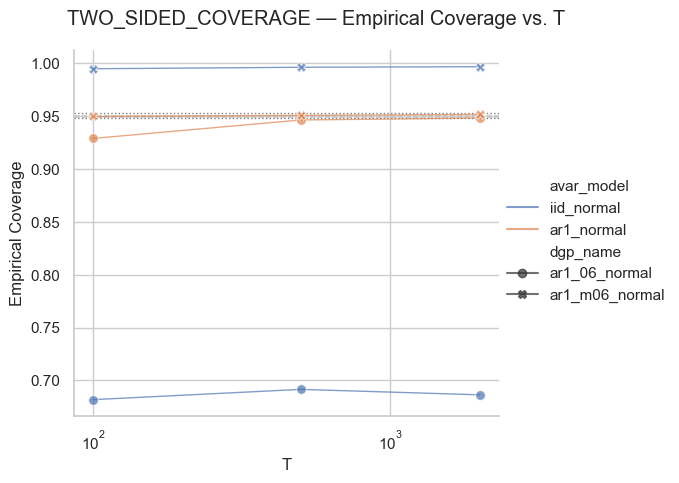

In [10]:
run_analysis(experiments, "serial", alpha=0.05, plot_mask=[0,1,1],
             line_plot_kargs=line_plot_kargs | 
             dict(log=True, markers=['o', 'X']))

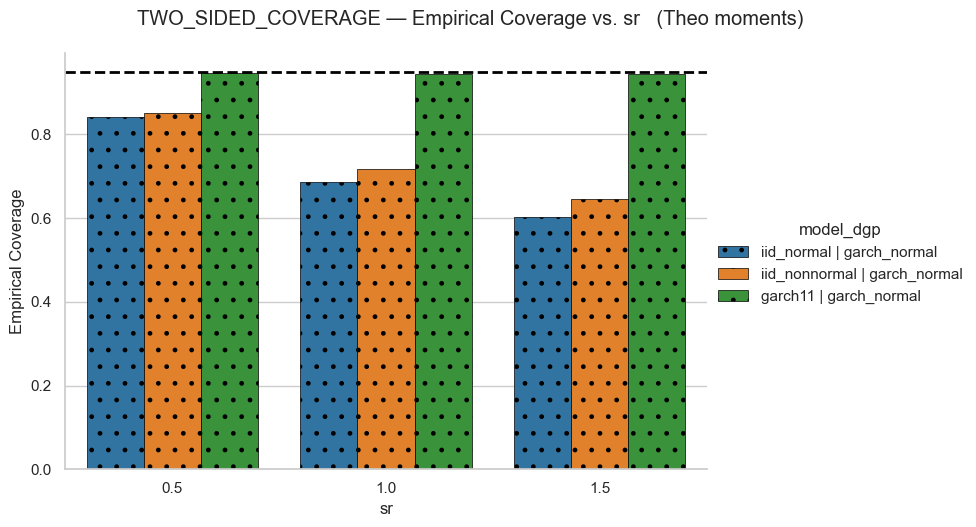

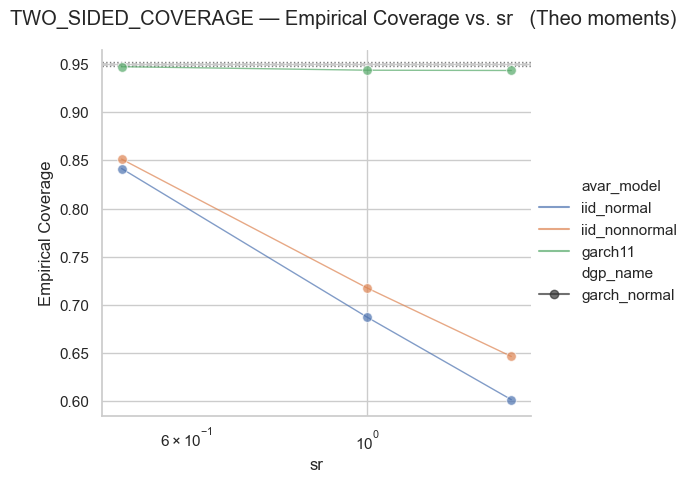

In [11]:
run_analysis(experiments, "hetero_tails", alpha=0.05, plot_mask=[0,1,1],
             line_plot_kargs=line_plot_kargs | 
             dict(log=True))

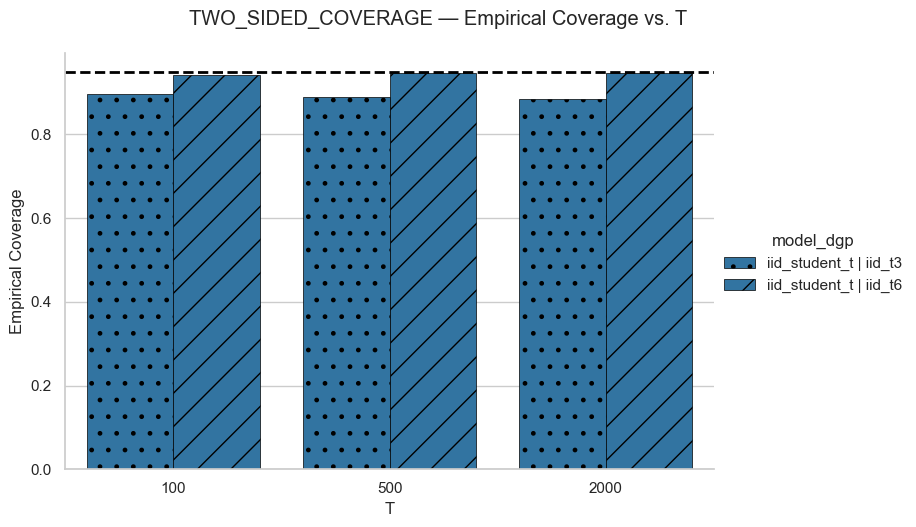

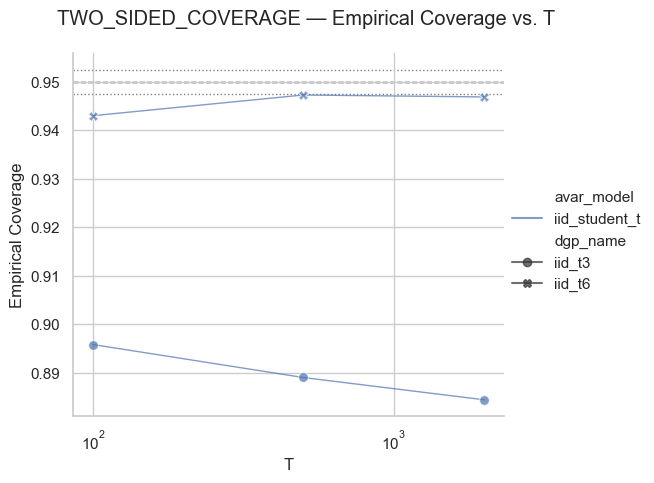

In [12]:
run_analysis(experiments, "non4", alpha=0.05, plot_mask=[0,1,1],
             line_plot_kargs=line_plot_kargs | 
             dict(log=True, markers=['o', 'X']))

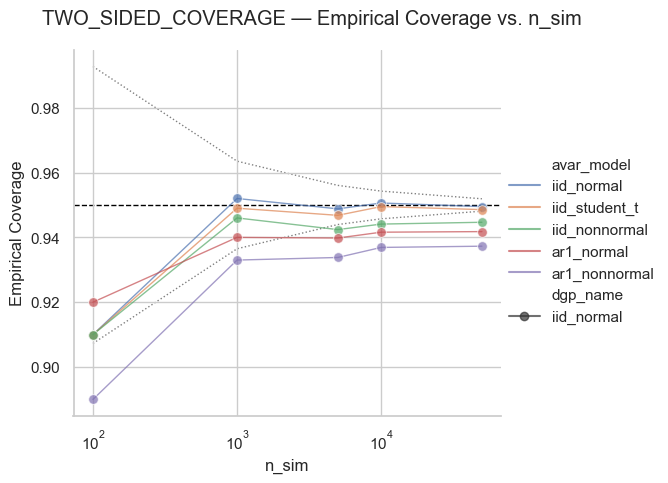

In [13]:
run_analysis(experiments, "efficiency", alpha=0.05, plot_mask=[0,0,1],
             line_plot_kargs=line_plot_kargs | 
             dict(log=True,))

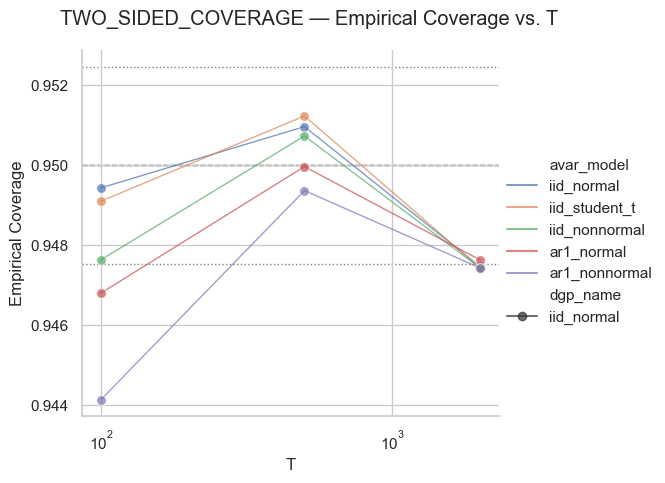

In [16]:
run_analysis(experiments, "efficiency", alpha=0.05, plot_mask=[0,0,1],
             line_plot_kargs=line_plot_kargs | 
             dict(log=True,))